# What role does the graph play?

The relative GLV puts every firm on a node of a sparse, heterogeneous interaction graph and lets it
compete with its neighbours:

$$\dot{x}_i = x_i\Big[1 - \frac{x_i}{m} - \frac{(\alpha x)_i}{m}\Big],\qquad m=\langle x\rangle,$$

with **own-degree** couplings $\alpha_{ij}=\mu/k_i + (\sigma/\sqrt{k_i})\,z_{ij}$ on the $k_i$
neighbours of firm $i$. Out of this come the firm-growth observables: a fat-tailed tent of growth
rates, a size–volatility law $\sigma(S)\sim S^{-\beta}$, and multiscaling — higher conditional
moments $E[\sigma^q\,|\,S]\sim S^{-\zeta_q}$ with $\zeta_q/\zeta_1$ *rising* in $q$.

The graph is the only structure in the model. So: **which of those observables does it actually
generate, and through what channel?** This notebook is the consolidated answer, in four legs.

| leg | question | verdict |
|---|---|---|
| **1** | does a firm's own degree set its volatility? | **no** — $\sigma\perp k$, $\delta\approx0$; $\beta$ is self-limitation, not hub-quieting |
| **2** | *why* is $\beta$ degree-blind? | the field's **variance** is flat in $k$. So is its **excess kurtosis** — a predicted $1/k$ granularity is **not there** |
| **3** | does topology move $\beta$, or the multiscaling? | $\beta$ **invariant**. And per economy $\zeta_4/\zeta_1=3.77$ against a no-multiscaling null of $4$ — the model makes ~a fifth of MSB's multiscaling, and the graph-free `fc` control makes none |
| **4** | are the firm roles quenched or emergent? | **quenched** — the couplings assign them, the dynamics do not |

**The claim these four support.** Own-degree normalization is a *variance* normalization, and on this
graph it turns out to neutralize the degree channel almost completely:

- **second moment** — the $1/\sqrt{k}$ coupling exactly cancels the $\sqrt{k}$ of the neighbour sum,
  so every firm feels a forcing of the same strength regardless of degree. The single-site problem is
  degree-free at second order $\Rightarrow$ $\sigma\perp k$ $\Rightarrow$ $\beta$ does not move when
  you change the graph, or when you delete it.
- **higher moments** — one might expect the normalization to miss these, leaving a $\sim1/k$
  granularity (a hub averages many neighbours into a near-Gaussian field; a leaf tracks a handful of
  fat-tailed ones), and hence multiscaling driven by the degree tail. **§2 measures the field directly
  and finds no such $1/k$ trend**, and §3 confirms the consequence: measured *inside* each economy,
  $\zeta_4/\zeta_1\approx3.8$ for every topology and for the graph-free control alike.

So the multiscaling is a property of the disorder and the dynamics, not of the topology. What the
graph and its couplings *do* determine is **which firm plays which role**: fix $\alpha$, vary only the
initial condition, and the same firms come out big ($\rho=0.93$) and the same firms come out volatile
($\rho=0.82$). The roles are frozen at the moment the disorder is drawn.

Compressed: **the graph sets *who*, not *how much*.** Which is also why disorder-averaged DMFT order
parameters — which integrate the realization away — recover $\beta$ but have nothing to say about the
firm-to-firm structure.

> ### A methodological warning, which turned out to carry the physics
>
> Two estimator habits inherited from the older notebooks and from `scripts/msb_conditional.py`
> generate confident, wrong answers here, and neither fails loudly:
>
> 1. **Fitting $\sigma(S)$ across both branches.** The immigration floor's rising plateau drags
>    $\beta$ from 0.86 to 0.11 and flips the sign of the size partial. (§1)
> 2. **Pooling economies before conditioning on $S$.** Each realization of $\alpha$ has its own
>    volatility scale — here spanning $\sim\!10^3$ — so pooling 20 of them measures a single economy
>    with 20 disconnected components. The resulting $\zeta_q$ **does not converge**: pooling 5, 20 and
>    80 economies gives $3.34$, $2.89$ and $2.53$, and the spread across repeated draws never shrinks,
>    because the pooled $E[\sigma^4|S]$ is dominated by each bin's few most volatile firms — an
>    extreme-value statistic, not an average. The number you report is a function of your seed count.
>    (§1, §3)
>
> Habit 2 produced the previously-reported result that the degree tail tunes the multiscaling
> ($\rho=-0.90$, $p=0.04$), and also the celebrated "own-degree sits on MSB's 2.9" — the pooled curve
> passes through 2.9 at exactly the 20 seeds those notebooks ran. Bootstrap-over-economy error bars do
> not catch this; they measure the sampling variance of an estimator that has no limit.
>
> There is also a **reference-line error**. Under this estimator ($\zeta_q$ from
> $\log E[\sigma^q|S]$ vs $\log S$) the no-multiscaling null is $\zeta_q/\zeta_1=q$, i.e. $1,2,3,4$ —
> *not* the $1,1,1,1$ the old notebooks drew and labelled "granular". That flat line is the null of the
> $q$-th-root convention, and plotting it against this estimator makes any rise in $q$ look like a
> triumph. The quenched measurement is $\zeta_4/\zeta_1=3.769$ (95% CI $[3.73,3.83]$, 297 economies),
> i.e. **6% concavity where MSB report 27%**, and the graph-free `fc` control sits at $4.03\pm0.03$ —
> exactly simple scaling.
>
> **This notebook therefore contradicts three claims in the older `notebooks/README.md` arc:** the
> field's excess kurtosis does *not* go as $1/k$; the degree-tail ordering of the multiscaling is a
> pool-size artifact; and `pl2.5`'s $\zeta_4/\zeta_1=2.90$ does *not* match MSB's 2.9. **The model
> produces roughly a fifth of the observed multiscaling, not all of it.**

---

### Running this notebook

Every section is **load-or-compute**. By default it reads the cached aggregates in `data/*.npz` and
re-plots in seconds. To re-integrate a section from scratch, name its tag:

```bash
GRAPH_ROLE_RECOMPUTE=deg      jupyter nbconvert --execute --inplace notebooks/graph_role.ipynb
GRAPH_ROLE_RECOMPUTE=all      jupyter nbconvert --execute --inplace notebooks/graph_role.ipynb
```

Tags: `deg` (§1), `field` (§2), `topo` (§3), `quench` (§4), or `all`. A section also recomputes
automatically when its cache is absent. Recomputing widens some figures: the cached `.npz` for §2 and
§4 hold binned curves and scalars but not the raw per-firm clouds, so the scatter panels appear only
on a fresh run.

> This notebook folds in and replaces the four separate notebooks `degree_volatility`,
> `field_granularity`, `topology_multiscaling` and `quench_test`.

In [1]:
import os, sys, time
while not os.path.isdir("relative_glv") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                                          # run from repo root OR notebooks/
sys.path.insert(0, os.getcwd())
import numpy as np
import networkx as nx
from scipy import sparse
from scipy.stats import kurtosis, spearmanr, laplace
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
from joblib import Parallel, delayed
from relative_glv.model import coupling, integrate
from relative_glv.msb import size_volatility, tent_stats, rescale

# ---- locked own-degree operating point, shared by all four legs -----------------------------
MU, SIGMA, LAM = 1.76, 1.75, 1e-3       # mean competition, disorder, immigration floor
C = 100                                 # mean degree, matched across topologies
NJOBS = 8

# ---- load-or-compute -------------------------------------------------------------------------
RECOMPUTE = set(filter(None, os.environ.get("GRAPH_ROLE_RECOMPUTE", "").split(",")))

def stale(tag, path):
    """Recompute this section if it was asked for by tag, or if its cache is missing."""
    return tag in RECOMPUTE or "all" in RECOMPUTE or not os.path.exists(path)

COLS = {"regular": "#1d3557", "exponential": "#2a9d8f", "pl2.5": "#e76f51",
        "pl3.5": "#457b9d", "fc": "#e9c46a"}
print(f"mu={MU} sigma={SIGMA} lam={LAM}  C={C}   recompute={sorted(RECOMPUTE) or 'nothing (load cached)'}")

mu=1.76 sigma=1.75 lam=0.001  C=100   recompute=nothing (load cached)


In [2]:
# ---- shared helpers (were copy-pasted across the four source notebooks) -----------------------

def binmed(x, y, nb):
    """Median y per equal-count bin of x. y may be negative (kurtosis), so no positivity mask."""
    o = np.argsort(x)
    P = np.array_split(np.arange(o.size), nb)
    bx = np.array([x[o][p].mean() for p in P])
    by = np.array([np.median(y[o][p]) for p in P])
    return bx, by

def slope(x, y):
    """Least-squares log-log slope and R^2, over the strictly-positive points."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan, np.nan
    lx, ly = np.log10(x[m]), np.log10(y[m])
    c = np.polyfit(lx, ly, 1)
    yh = np.polyval(c, lx)
    ss = np.sum((ly - ly.mean()) ** 2)
    return c[0], (1 - np.sum((ly - yh) ** 2) / ss if ss > 0 else np.nan)

def linslope(x, y):
    """Least-squares slope of y against log10(x), R^2. For SIGNED y -- the field's excess kurtosis
    is negative everywhere, so a log-log slope is undefined and slope() would return nan."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = (x > 0) & np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan, np.nan
    lx = np.log10(x[m])
    c = np.polyfit(lx, y[m], 1)
    yh = np.polyval(c, lx)
    ss = np.sum((y[m] - y[m].mean()) ** 2)
    return c[0], (1 - np.sum((y[m] - yh) ** 2) / ss if ss > 0 else np.nan)

def degree_seq(topo, N, rng):
    """Degree sequence with mean ~C; the topologies differ only in tail / variance."""
    if topo == "regular":
        return np.full(N, C, float)                          # zero degree variance
    if topo == "exponential":
        return np.maximum(rng.exponential(C, N), 1.0)        # finite var ~C^2, light tail
    a = 2.5 if topo == "pl2.5" else 3.5                      # pl2.5 infinite var; pl3.5 finite var
    kmin = C * (a - 2) / (a - 1)                             # sets mean = C
    return np.maximum(kmin * (1 - rng.uniform(size=N)) ** (-1 / (a - 1)), 1.0)

def owndeg_alpha(topo, N, mu, sigma, seed):
    """Own-degree couplings on an arbitrary degree distribution.

    EXACT mirror of coupling()'s powerlaw_owndeg path (verified bit-identical for pl2.5): one rng
    stream, degrees drawn first then couplings, a_ij = mu/k_i + (sigma/sqrt(k_i)) z_ij.
    """
    rng = np.random.default_rng(seed)
    deg = np.maximum(np.round(degree_seq(topo, N, rng)).astype(int), 1)
    if deg.sum() % 2:
        deg[deg.argmin()] += 1
    G = nx.Graph(nx.configuration_model(deg.tolist(), seed=int(seed)))
    G.remove_edges_from(nx.selfloop_edges(G))
    A = nx.to_scipy_sparse_array(G, format="csr", dtype=float)
    ki = np.diff(A.indptr).astype(float); ki[ki == 0] = 1.0
    coo = A.tocoo()
    z = rng.normal(size=coo.row.size)
    vals = mu / ki[coo.row] + (sigma / np.sqrt(ki[coo.row])) * z
    return sparse.csr_array((vals, (coo.row, coo.col)), shape=(N, N)), ki

def multiscaling(Sbar, vol, econ, nb=20, nboot=200):
    """zeta_1..4 from E[sigma^q|S] ~ S^-zeta_q on the decline branch, with bootstrap-over-economy
    error bars. Mirrors scripts/msb_conditional.py. zeta_1 == beta."""
    live = (vol > 0) & np.isfinite(vol) & (Sbar > 0)
    Sbar, vol, econ = Sbar[live], vol[live], econ[live]
    o = np.argsort(Sbar); P = np.array_split(np.arange(o.size), nb)
    bx = np.array([Sbar[o][p].mean() for p in P]); by = np.array([np.median(vol[o][p]) for p in P])
    m = (bx > 0) & (by > 0); bx, by = bx[m], by[m]
    pk = int(np.argmax(by)); Scut = bx[pk]; dec = Sbar > Scut     # fit the large-S decline branch only
    nfit = max(6, nb - pk)
    def cq_of(Sx, vx):
        ox = np.argsort(Sx); Px = np.array_split(np.arange(ox.size), nfit)
        bxx = np.array([Sx[ox][p].mean() for p in Px]); out = []
        for q in (1, 2, 3, 4):
            byy = np.array([np.mean(vx[ox][p] ** q) for p in Px])
            mm = (bxx > 0) & (byy > 0)
            out.append(-np.polyfit(np.log10(bxx[mm]), np.log10(byy[mm]), 1)[0])
        return np.array(out)
    cq = cq_of(Sbar[dec], vol[dec])
    ue = np.unique(econ[dec]); rbs = np.random.default_rng(0); boot = []
    if ue.size >= 2:
        for _ in range(nboot):
            pick = rbs.choice(ue, ue.size, replace=True)
            ix = np.concatenate([np.where(econ[dec] == e)[0] for e in pick])
            boot.append(cq_of(Sbar[dec][ix], vol[dec][ix]))
        boot = np.array(boot); cq_err = boot.std(0); ratio_err = (boot / boot[:, [0]]).std(0)
    else:
        cq_err = ratio_err = np.full(4, np.nan)
    return dict(cq=cq, cq_err=cq_err, ratio=cq / cq[0], ratio_err=ratio_err, ndec=int(dec.sum()))

def decline_fit(S, v, nb):
    """beta and the decline cut for ONE economy, on its OWN peak. Returns (beta, Scut, pk) or None."""
    live = (v > 0) & np.isfinite(v) & (S > 0)
    S, v = S[live], v[live]
    if S.size < 200:
        return None
    bx, by = binmed(S, v, nb)
    m = (bx > 0) & (by > 0); bx, by = bx[m], by[m]
    pk = int(np.argmax(by))
    if by.size - pk < 4:
        return None
    b, _ = slope(bx[pk:], by[pk:])
    return -b, float(bx[pk]), pk

def cq_one(S, v, nb):
    """zeta_1..4 for ONE economy, on its OWN decline branch. The pooling-free estimator.

    Pooling economies before conditioning on S is not innocent: each realization has its own
    volatility scale (median sigma spans ~1000x here) and its own survivor set, so E[sigma^q | S]
    averages a quiet economy's large firms against a loud economy's small ones. That injects
    S-independent variance, flattens the fitted slope, and biases zeta_q DOWNWARD -- worse at large q,
    and worse the more the economies differ. Effectively you are measuring one graph with `seeds`
    disconnected components, which is a different topology from any of them.
    """
    live = (v > 0) & np.isfinite(v) & (S > 0)
    S, v = S[live], v[live]
    if S.size < 200:
        return None
    o = np.argsort(S); P = np.array_split(np.arange(o.size), nb)
    bx = np.array([S[o][p].mean() for p in P]); by = np.array([np.median(v[o][p]) for p in P])
    m = (bx > 0) & (by > 0); bx, by = bx[m], by[m]
    pk = int(np.argmax(by)); dec = S > bx[pk]; nfit = max(6, nb - pk)
    if dec.sum() < 200:
        return None
    Sx, vx = S[dec], v[dec]
    ox = np.argsort(Sx); Px = np.array_split(np.arange(ox.size), nfit)
    bxx = np.array([Sx[ox][p].mean() for p in Px]); out = []
    for q in (1, 2, 3, 4):
        byy = np.array([np.mean(vx[ox][p] ** q) for p in Px])
        mm = (bxx > 0) & (byy > 0)
        if mm.sum() < 3:
            return None
        out.append(-np.polyfit(np.log10(bxx[mm]), np.log10(byy[mm]), 1)[0])
    c = np.array(out)
    return c if c[0] > 0 else None

def fe_ols(y, X, econ):
    """OLS of y on X with one intercept PER ECONOMY (fixed effects). Returns the X coefficients.
    Absorbs each realization's own volatility level, which a single pooled intercept cannot."""
    u = np.unique(econ)
    D = (econ[:, None] == u[None, :]).astype(float)
    coef, *_ = np.linalg.lstsq(np.hstack([D, X]), y, rcond=None)
    return coef[len(u):]

def subsample(a, n=40000):
    """Thin an array for storage in the npz (the scatter clouds are only ever plotted)."""
    a = np.asarray(a)
    return a[::max(1, a.size // n)].astype(np.float32)

---

## §1 — Degree → volatility → size

The thesis asserts the size–volatility law $\sigma(S)\sim S^{-\beta}$ comes from own-degree
normalization *quieting the hubs*: high-degree firms are over-stabilized, and since hubs grow big,
big firms end up quiet. But every measurement in that chain is $\sigma$ against **size**, never
$\sigma$ against **degree**. The middle of the argument is never observed. Open it.

The trick needs no library change: for `kind="powerlaw_owndeg"`, `coupling()` returns a sparse matrix
whose row structure *is* the graph, so firm $i$'s degree is `np.diff(alpha.indptr)[i]` — degree comes
straight back out of $\alpha$.

Three legs:

1. $\sigma\sim k^{-\delta}$ — the direct test. **Is volatility set by degree?**
2. $\bar S\sim k^{\theta}$ — the link. **Do hubs become the big firms?**
3. joint OLS of $\log\sigma$ on $\log S$ **and** $\log k$ — the referee. **Which is the driver, which the proxy?**

If $\delta\approx0$ the asserted mechanism is simply not there, and $\beta$ must come from the
dynamics (a firm's own size self-limiting its growth) rather than from the couplings.

Settings are matched to §3 (N=2000, 20 seeds, tmax=300) — the original notebook ran this leg at
"quick settings" (N=1500, 4 seeds), weaker than the other three.

Two estimator choices matter enormously here, and both are easy to get wrong silently.

> **1. Fit on the decline branch $S>S_\ast$**, where $S_\ast$ is the peak of the binned $\sigma(S)$
> curve. This is how $\beta$ is defined everywhere else in the repo (`_decline_beta` in `msb.py`).
> The immigration floor $\lambda$ pins the smallest firms into a *rising* $\sigma(S)$ plateau, and a
> fit spanning both branches measures neither — it returns $\beta\approx0.11$, against
> $\beta\approx0.86$ on the decline branch. The cell prints both.
>
> **2. Do not pool economies.** Each realization of $\alpha$ is its own world: the per-economy median
> volatility here spans a factor of $\sim\!10^3$, the survivor sets differ, and each has its own
> $S_\ast$ (0.07 to 0.85). Concatenating 20 of them and conditioning on $S$ is measuring one economy
> made of 20 disconnected components — a different graph from any of them. At a given $S$ you are then
> averaging a quiet economy's large firms against a loud economy's small ones, which adds
> $S$-independent variance and **flattens the fitted slope**. The cell reports $\beta$ per economy
> (the estimate to quote), the pooled value, and a regression with **one intercept per economy**
> (fixed effects) that absorbs each world's own volatility level.

In [3]:
# ---- §1  load-or-compute ---------------------------------------------------------------------
P1 = "data/degree_volatility.npz"
NB1 = 18

if stale("deg", P1):
    N1, SEEDS1 = 2000, 20
    TMAX1, NEVAL1, LATE1, DT1 = 300.0, 700, (230.0, 290.0), 0.5

    def sim_deg(seed):
        """One own-degree economy -> per-survivor (degree, mean size, volatility).
        k is recovered from alpha and masked exactly as size_volatility masks survivors."""
        a = coupling(N1, MU, SIGMA, kind="powerlaw_owndeg", seed=seed)
        k = np.diff(a.indptr).astype(float)
        r = integrate(a, tmax=TMAX1, n_eval=NEVAL1, lam=LAM, seed=seed,
                      method="RK45", rtol=1e-4, atol=1e-7)
        if not r["success"]:
            return None
        sv = size_volatility(r["W"], r["t"], window=LATE1, dt=DT1, n_bins=NB1)
        if sv["Sbar"].size == 0 or not np.isfinite(sv["beta"]):
            return None
        win = (r["t"] >= LATE1[0]) & (r["t"] <= LATE1[1])       # same survivor mask, index order
        live = r["W"][:, win].min(1) > 1e-6
        return dict(seed=seed, k=k[live], Sbar=sv["Sbar"], vol=sv["vol"], beta=sv["beta"])

    t0 = time.time()
    recs = [x for x in Parallel(n_jobs=NJOBS, backend="loky")(
        delayed(sim_deg)(s) for s in range(SEEDS1)) if x is not None]
    assert recs, "no economies survived integration"
    k    = np.concatenate([x["k"]    for x in recs])
    Sbar = np.concatenate([x["Sbar"] for x in recs])
    vol  = np.concatenate([x["vol"]  for x in recs])
    econ = np.concatenate([np.full(x["Sbar"].size, x["seed"]) for x in recs])   # which economy each firm is from
    good = np.isfinite(vol) & (vol > 0) & (Sbar > 0) & (k > 0)
    k, Sbar, vol, econ = k[good], Sbar[good], vol[good], econ[good]
    print(f"integrated {len(recs)}/{SEEDS1} economies in {(time.time()-t0)/60:.1f} min; {k.size} firms")

    # ---- the honest estimator: beta PER ECONOMY, each on its own decline branch ---------------
    fits = [f for f in (decline_fit(x["Sbar"], x["vol"], NB1) for x in recs) if f is not None]
    assert fits, "no economy yielded a decline branch"
    beta_each = np.array([f[0] for f in fits])
    Scut_each = np.array([f[1] for f in fits])
    medvol_each = np.array([np.median(x["vol"][x["vol"] > 0]) for x in recs])

    # ---- the pooled estimator, for contrast. Bin by size, find ONE peak, keep S > S*. -----------
    # This is what the repo has always done (msb._decline_beta on pooled arrays, scripts/
    # msb_conditional.py). It mixes economies with wildly different volatility levels.
    sx_v, sy_v = binmed(Sbar, vol, NB1)
    pk = int(np.argmax(sy_v)); Scut = sx_v[pk]; dec = Sbar > Scut
    beta_full, _     = slope(sx_v, sy_v);           beta_full = -beta_full   # both branches: nonsense
    beta_pool, r2_sv = slope(sx_v[pk:], sy_v[pk:]); beta_pool = -beta_pool   # decline, but pooled

    kx_v, ky_v = binmed(k[dec], vol[dec],  NB1)   # leg 1: sigma vs k
    kx_s, ky_s = binmed(k[dec], Sbar[dec], NB1)   # leg 2: Sbar vs k
    delta, r2_dv = slope(kx_v, ky_v); delta = -delta
    theta, r2_ts = slope(kx_s, ky_s)

    # ---- leg 3: partial OLS, pooled vs economy fixed effects -----------------------------------
    y = np.log10(vol[dec]); lS = np.log10(Sbar[dec]); lk = np.log10(k[dec])
    cp, *_ = np.linalg.lstsq(np.column_stack([np.ones(y.size), lS, lk]), y, rcond=None)
    b_pool, c_pool = cp[1], cp[2]
    b_fe, c_fe = fe_ols(y, np.column_stack([lS, lk]), econ[dec])   # one intercept per economy

    D1 = dict(kx_v=kx_v, ky_v=ky_v, kx_s=kx_s, ky_s=ky_s, sx_v=sx_v, sy_v=sy_v, pk=pk, Scut=Scut,
              delta=delta, theta=theta, beta_pool=beta_pool, beta_full=beta_full,
              beta_each=beta_each, Scut_each=Scut_each, medvol_each=medvol_each,
              b_pool=b_pool, c_pool=c_pool, b_fe=b_fe, c_fe=c_fe,
              r2_dv=r2_dv, r2_ts=r2_ts, r2_sv=r2_sv,
              k_sc=subsample(k), S_sc=subsample(Sbar), v_sc=subsample(vol),
              N=N1, seeds=len(recs), nfirms=k.size, ndec=int(dec.sum()))
    np.savez(P1, **D1)
    print(f"saved {P1}")
else:
    D1 = {kk: np.load(P1)[kk] for kk in np.load(P1).files}
    print(f"loaded {P1}  (N={D1['N']} x {D1['seeds']} seeds, {D1['nfirms']} firms)")

be = D1["beta_each"]; nE = be.size
bp, bfull = float(D1["beta_pool"]), float(D1["beta_full"])
d, th = float(D1["delta"]), float(D1["theta"])
b_pool, c_pool, b_fe, c_fe = (float(D1[x]) for x in ("b_pool", "c_pool", "b_fe", "c_fe"))
Scut, ndec = float(D1["Scut"]), int(D1["ndec"])
mv = D1["medvol_each"]

print(f"\n--- the economies are NOT one world -------------------------------------------------")
print(f"  per-economy median volatility spans {mv.min():.5f} .. {mv.max():.5f}  "
      f"({mv.max()/max(mv.min(),1e-12):.0f}x)")
print(f"  per-economy own S*  spans {D1['Scut_each'].min():.2f} .. {D1['Scut_each'].max():.2f}   "
      f"(the pooled fit imposes one S* = {Scut:.2f})")

print(f"\n--- beta -----------------------------------------------------------------------------")
print(f"  PER-ECONOMY (each on its own decline branch)  = {be.mean():.3f} +- {be.std()/np.sqrt(nE):.3f} (sem)"
      f"   sd {be.std():.3f}, n={nE}   <- the estimate to quote")
print(f"  pooled, one common S* = {Scut:.2f}            = {bp:.3f}   <- biased by mixing economies")
print(f"  pooled, fitted across BOTH branches           = {bfull:.3f}   <- meaningless (floor plateau)")

print(f"\n--- leg 1 & 2: is degree doing anything? ---------------------------------------------")
print(f"  sigma ~ k^-delta    delta = {d:+.3f}  (R2={float(D1['r2_dv']):.2f})   [degree -> volatility]")
print(f"  Sbar  ~ k^theta     theta = {th:+.3f}  (R2={float(D1['r2_ts']):.2f})   [degree -> size]")
print(f"  both ~0: there is no degree->size->volatility channel to account for")

print(f"\n--- leg 3: the referee.  log sigma = a + b logS + c logk   (decline branch, n={ndec}) ---")
print(f"  {'':<26}{'b (size)':>10}{'c (degree)':>12}")
print(f"  {'pooled, one intercept':<26}{b_pool:>10.3f}{c_pool:>12.3f}")
print(f"  {'economy fixed effects':<26}{b_fe:>10.3f}{c_fe:>12.3f}   <- absorbs each economy's own sigma level")
print(f"\n  -> SIZE drives (b recovers -beta). The degree partial falls from {c_pool:+.3f} to {c_fe:+.3f}")
print(f"     once each economy gets its own intercept: the apparent degree effect was POOLING,")
print(f"     not degree. With fixed effects c is ~{abs(c_fe):.2f} -- indistinguishable from nothing.")

loaded data/degree_volatility.npz  (N=2000 x 20 seeds, 13178 firms)

--- the economies are NOT one world -------------------------------------------------
  per-economy median volatility spans 0.00004 .. 0.13996  (3179x)
  per-economy own S*  spans 0.07 .. 0.85   (the pooled fit imposes one S* = 0.70)

--- beta -----------------------------------------------------------------------------
  PER-ECONOMY (each on its own decline branch)  = 0.804 +- 0.012 (sem)   sd 0.052, n=20   <- the estimate to quote
  pooled, one common S* = 0.70            = 0.856   <- biased by mixing economies
  pooled, fitted across BOTH branches           = 0.107   <- meaningless (floor plateau)

--- leg 1 & 2: is degree doing anything? ---------------------------------------------
  sigma ~ k^-delta    delta = -0.030  (R2=0.05)   [degree -> volatility]
  Sbar  ~ k^theta     theta = +0.035  (R2=0.28)   [degree -> size]
  both ~0: there is no degree->size->volatility channel to account for

--- leg 3: the referee.

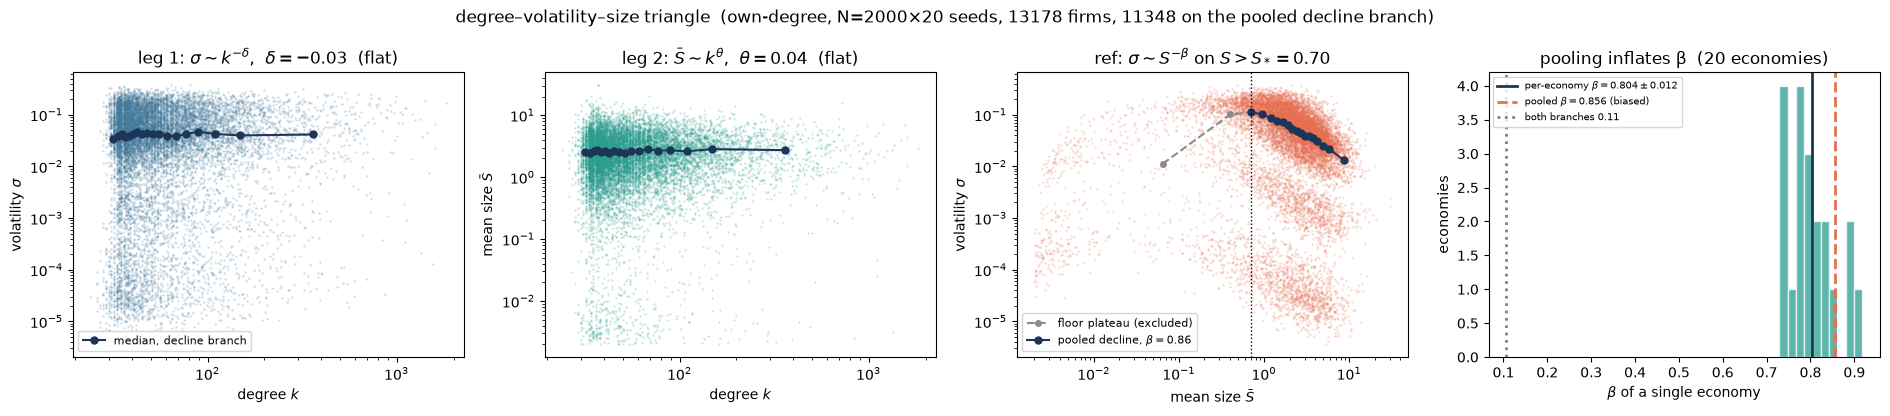

In [4]:
# ---- §1  figure ------------------------------------------------------------------------------
fig, ax = plt.subplots(1, 4, figsize=(19, 4.2))
sc = dict(marker=".", ms=2, ls="none")

ax[0].loglog(D1["k_sc"], D1["v_sc"], alpha=0.15, color="#457b9d", **sc)
ax[0].loglog(D1["kx_v"], D1["ky_v"], "o-", ms=5, color="#1d3557", label="median, decline branch")
ax[0].set(xlabel=r"degree $k$", ylabel=r"volatility $\sigma$",
          title=fr"leg 1: $\sigma\sim k^{{-\delta}}$,  $\delta={d:.2f}$  (flat)")
ax[0].legend(fontsize=8, loc="lower left")

ax[1].loglog(D1["k_sc"], D1["S_sc"], alpha=0.15, color="#2a9d8f", **sc)
ax[1].loglog(D1["kx_s"], D1["ky_s"], "o-", ms=5, color="#1d3557")
ax[1].set(xlabel=r"degree $k$", ylabel=r"mean size $\bar S$",
          title=fr"leg 2: $\bar S\sim k^{{\theta}}$,  $\theta={th:.2f}$  (flat)")

pk = int(D1["pk"])
ax[2].loglog(D1["S_sc"], D1["v_sc"], alpha=0.15, color="#e76f51", **sc)
ax[2].loglog(D1["sx_v"][:pk + 1], D1["sy_v"][:pk + 1], "o--", ms=4, color="0.55",
             label="floor plateau (excluded)")
ax[2].loglog(D1["sx_v"][pk:], D1["sy_v"][pk:], "o-", ms=5, color="#1d3557",
             label=fr"pooled decline, $\beta={bp:.2f}$")
ax[2].axvline(Scut, color="k", ls=":", lw=1)
ax[2].set(xlabel=r"mean size $\bar S$", ylabel=r"volatility $\sigma$",
          title=fr"ref: $\sigma\sim S^{{-\beta}}$ on $S>S_*={Scut:.2f}$")
ax[2].legend(fontsize=8, loc="lower left")

# per-economy beta vs the pooled number: the pooling bias, made visible
ax[3].hist(be, bins=10, color="#2a9d8f", alpha=0.75, edgecolor="w")
ax[3].axvline(be.mean(), color="#1d3557", lw=2,
              label=fr"per-economy $\beta={be.mean():.3f}\pm{be.std()/np.sqrt(nE):.3f}$")
ax[3].axvline(bp, color="#e76f51", lw=2, ls="--", label=fr"pooled $\beta={bp:.3f}$ (biased)")
ax[3].axvline(bfull, color="0.5", lw=2, ls=":", label=fr"both branches ${bfull:.2f}$")
ax[3].set(xlabel=r"$\beta$ of a single economy", ylabel="economies",
          title=f"pooling inflates β  ({nE} economies)")
ax[3].legend(fontsize=7, loc="upper left")

fig.suptitle(f"degree–volatility–size triangle  (own-degree, N={int(D1['N'])}×{int(D1['seeds'])} seeds, "
             f"{int(D1['nfirms'])} firms, {ndec} on the pooled decline branch)")
plt.tight_layout(); plt.savefig("data/degree_volatility.png", dpi=120); plt.show()

**Reading the triangle.** The left panel is flat: $\delta\approx-0.03$, so a firm's degree tells you
essentially nothing about its volatility. The middle panel is flat too: $\theta\approx0.04$, hubs are
barely larger than leaves. Yet the third panel gives a clean $\sigma\sim S^{-\beta}$ with
$R^2\approx0.98$ — the size law is emphatically there, and has nothing to do with degree. The
consistency check $\theta\beta\stackrel{?}{=}\delta$ is vacuous: both sides are $\approx0.03$ in
magnitude, so there is no degree$\to$size$\to$volatility channel to account for.

**The number to quote is $\beta = 0.804\pm0.012$ (sem over 20 economies), not the pooled $0.856$.**
The fourth panel shows why: individual economies scatter over $\beta\in[0.73,0.92]$, and the pooled
fit sits above their mean. Pooling mixes worlds with volatility levels differing by $\sim\!10^3$, and
the mixture is not the average.

The referee (leg 3) is where pooling does real damage. With a single pooled intercept, the degree
partial reads $c=+0.147$ — small, but apparently a real signal that hubs are *noisier* at fixed size.
Give each economy its own intercept and it collapses to $c=+0.034$: **the apparent degree effect was
pooling, not degree.** Economies that happen to have more hubs also happen to be louder overall, and a
single intercept cannot tell those apart. The size partial barely moves ($-0.892\to-0.839$, still
recovering $-\beta$).

So every route into the degree channel comes back null, and the one that looked marginally non-null
was an artifact. **$\beta$ lives in the dynamics — a firm's own size limits its own growth — not in
the couplings.** The graph is not what makes big firms quiet.

Which raises the sharper question: firm $i$ has $k_i$ neighbours and couplings scaled $1/\sqrt{k_i}$.
How can a hub with $k=400$ and a leaf with $k=30$ possibly experience the *same* volatility? That is
§2.

---

## §2 — Why $\beta$ is degree-blind: the field a firm feels

§1 leaves a puzzle. Firm $i$ has $k_i$ neighbours and couplings scaled $1/\sqrt{k_i}$. Surely a hub
with $k=2000$ and a leaf with $k=3$ live in different worlds? Look directly at the object that
mediates everything: the **interaction field**

$$h_i(t) = (\alpha S)_i = \sum_j \alpha_{ij}\,S_j(t),$$

one sparse matmul away from the trajectory. Measure, per firm, the *temporal* moments of $h_i(t)$
over the late window, and read them against degree. We also split off the deterministic mean part
$\mu k_i^{-1}\sum_{j\in\partial i}S_j$ to isolate the $\sigma/\sqrt{k_i}$ disorder channel.

**Predictions, if own-degree is exactly a variance normalization** — and what actually came out:

| quantity | prediction | consequence if true | **outcome** |
|---|---|---|---|
| $\mathrm{Var}_t[h_i]$ | **flat in $k$**, $\approx\sigma^2\langle\mathrm{Var}_t S\rangle$ | the $1/\sqrt{k}$ cancels the $\sqrt{k}$ of the sum $\Rightarrow$ $\beta$ invariant | ✅ confirmed, slope $+0.04$ |
| growth volatility $\sigma_i$ | flat in $k$ | the §1 null, one step downstream | ✅ confirmed, slope $+0.00$ |
| excess kurtosis of $h_i$ | $\propto 1/k$ | hubs average neighbours into near-Gaussian noise; leaves track a few fat-tailed $S_j(t)$ $\Rightarrow$ multiscaling would track the degree tail | ❌ **refuted** — flat, and *negative* |

The third row is the interesting one, so state the prediction sharply before killing it. Own-degree
normalizes the *variance*; there is no obvious reason it should reach the fourth moment. A hub sums
$k\!=\!400$ neighbours, a leaf sums $k\!=\!30$; by any central-limit intuition the hub's field should
be closer to Gaussian, with the excess kurtosis decaying like $1/k$. If so, a scale-free degree tail
would hand different firms different amounts of non-Gaussianity, correlated with their size — which is
what multiscaling *is*. It is a clean mechanism, and it would explain everything.

It is also, as measured below, not what happens. A log-log slope is undefined for the excess kurtosis
because **every binned value is negative**, so we fit it linearly against $\log_{10}k$ instead — the
right tool for a signed quantity, and one that would still show a $1/k$ decay as a steep downward
trend if one existed.

Topology is pl2.5 own-degree (the thesis model), whose degree range is widest, giving any $1/k$ trend
the most leverage it can possibly get.

In [5]:
# ---- §2  load-or-compute ---------------------------------------------------------------------
P2 = "data/field_granularity.npz"
NB2 = 22

if stale("field", P2):
    N2, SEEDS2 = 3000, 8
    TMAX2, NEVAL2, LATE2, DT2 = 300.0, 700, (230.0, 290.0), 0.5

    def sim_field(seed):
        """One economy. Reconstruct h_i(t)=(alpha S)_i and return per-survivor temporal moments of
        the field -- total and disorder-only -- against degree."""
        a = coupling(N2, MU, SIGMA, kind="powerlaw_owndeg", seed=seed)
        k = np.diff(a.indptr).astype(float); k[k == 0] = 1.0
        r = integrate(a, tmax=TMAX2, n_eval=NEVAL2, lam=LAM, seed=seed,
                      method="RK45", rtol=1e-4, atol=1e-7)
        if not r["success"]:
            return None
        t, W = r["t"], r["W"]
        S = N2 * W                                                  # relative sizes (N, T)
        H = np.asarray(a @ S)                                       # the field itself
        Ab = a.copy(); Ab.data = np.ones_like(Ab.data)              # binary adjacency
        meanpart = MU * (np.asarray(Ab @ S) / k[:, None])           # mu/k_i sum_{j in di} S_j
        disorder = H - meanpart                                     # the sigma/sqrt(k) z-channel
        win = (t >= LATE2[0]) & (t <= LATE2[1])
        live = S[:, win].min(1) > 1e-6
        Hs = H[np.ix_(live, win)]; Ds = disorder[np.ix_(live, win)]; Ss = S[np.ix_(live, win)]
        g = np.diff(np.log(np.maximum(Ss, 1e-12)), axis=1)
        sig = np.sqrt(np.pi / 2) * np.abs(g - g.mean(1, keepdims=True)).mean(1)   # MAD-volatility
        return dict(k=k[live], fmean=Hs.mean(1), fvar=Hs.var(1), fexk=kurtosis(Hs, axis=1),
                    dexk=kurtosis(Ds, axis=1), sig=sig, vS=float(Ss.var(1).mean()))

    t0 = time.time()
    recs = [x for x in Parallel(n_jobs=NJOBS, backend="loky")(
        delayed(sim_field)(s) for s in range(SEEDS2)) if x is not None]
    assert recs, "no economies survived"
    K     = np.concatenate([x["k"]     for x in recs])
    fmean = np.concatenate([x["fmean"] for x in recs])
    fvar  = np.concatenate([x["fvar"]  for x in recs])
    fexk  = np.concatenate([x["fexk"]  for x in recs])
    dexk  = np.concatenate([x["dexk"]  for x in recs])
    sig   = np.concatenate([x["sig"]   for x in recs])
    vS = float(np.median([x["vS"] for x in recs]))       # sets the flat field-variance level
    ok = np.isfinite(K) & np.isfinite(fvar) & np.isfinite(fexk) & (K > 0)
    K, fmean, fvar, fexk, dexk, sig = [v[ok] for v in (K, fmean, fvar, fexk, dexk, sig)]
    print(f"integrated {len(recs)}/{SEEDS2} economies in {(time.time()-t0)/60:.1f} min; "
          f"{K.size} firms, k in [{K.min():.0f}, {K.max():.0f}]")

    kx, mean_b = binmed(K, fmean, NB2)
    _,  fvar_b = binmed(K, fvar,  NB2)
    _,  fexk_b = binmed(K, fexk,  NB2)
    _,  dexk_b = binmed(K, dexk,  NB2)
    _,  sig_b  = binmed(K, sig,   NB2)
    s_fvar, r2_fvar = slope(kx, fvar_b)      # expect  0 (flat)
    s_fexk, r2_fexk = slope(kx, fexk_b)      # expect -1 (~1/k)
    s_dexk, r2_dexk = slope(kx, dexk_b)      # expect -1 (~1/k)
    s_sig,  r2_sig  = slope(kx, sig_b)       # expect  0 (the leg-1 null)

    D2 = dict(N=N2, seeds=len(recs), vS=vS, k_bin=kx, fmean_bin=mean_b, fvar_bin=fvar_b,
              fexk_bin=fexk_b, dexk_bin=dexk_b, sig_bin=sig_b,
              slope_fvar=s_fvar, slope_fexk=s_fexk, slope_dexk=s_dexk, slope_sig=s_sig,
              r2_fvar=r2_fvar, r2_fexk=r2_fexk, r2_dexk=r2_dexk, r2_sig=r2_sig,
              ref_field_var=SIGMA ** 2 * vS,
              k_sc=subsample(K), fvar_sc=subsample(fvar), fexk_sc=subsample(fexk),
              sig_sc=subsample(sig))
    np.savez(P2, **D2)
    print(f"saved {P2}")
else:
    D2 = {kk: np.load(P2)[kk] for kk in np.load(P2).files}
    print(f"loaded {P2}  (N={D2['N']} x {D2['seeds']} seeds)")
    if "k_sc" not in D2:
        print("  note: cache predates the scatter subsample -> binned medians only. "
              "GRAPH_ROLE_RECOMPUTE=field restores the clouds.")

ref = float(D2["ref_field_var"])
kb, fexk_b, dexk_b = D2["k_bin"], D2["fexk_bin"], D2["dexk_bin"]

# The excess kurtosis is negative in EVERY bin, so a log-log slope does not exist (slope() -> nan).
# Fit it linearly against log10(k): a true ~1/k decay would still show as a steep downward trend.
s_fexk, r2_fexk = linslope(kb, fexk_b)
s_dexk, r2_dexk = linslope(kb, dexk_b)
kdec = np.log10(kb.max() / kb.min())                 # decades of degree covered

print(f"\nfield VAR    vs k : log-log slope = {float(D2['slope_fvar']):+.3f}   "
      f"predict 0 (flat); level ~ sigma^2<Var_t S> = {ref:.3f}")
print(f"growth sigma vs k : log-log slope = {float(D2['slope_sig']):+.3f}   predict 0 (the leg-1 null)")
print(f"\nfield EXKURT vs k over {kdec:.2f} decades of degree (k = {kb.min():.0f} .. {kb.max():.0f}):")
print(f"  all {int((fexk_b < 0).sum())}/{fexk_b.size} bins are NEGATIVE (sub-Gaussian): "
      f"range {fexk_b.min():+.2f} .. {fexk_b.max():+.2f}   -> no log-log slope exists")
print(f"  linear fit vs log10(k):   total field  slope = {s_fexk:+.3f} per decade  (R2={r2_fexk:.2f})")
print(f"                            disorder part slope = {s_dexk:+.3f} per decade  (R2={r2_dexk:.2f})")
print(f"  a true ~1/k decay would drop the kurtosis by a factor {10**kdec:.0f} across this range.")
print(f"  observed drop: {abs(fexk_b[-1] - fexk_b[0]):.2f} in absolute units, on a value of ~{fexk_b.mean():.2f}")
print(f"\n=> the 1/k granularity prediction is REFUTED: the field's non-Gaussianity is degree-flat,")
print(f"   so own-degree neutralizes the degree channel at the FOURTH moment too, not just the second.")

loaded data/field_granularity.npz  (N=3000 x 8 seeds)

field VAR    vs k : log-log slope = +0.042   predict 0 (flat); level ~ sigma^2<Var_t S> = 1.651
growth sigma vs k : log-log slope = +0.002   predict 0 (the leg-1 null)

field EXKURT vs k over 1.15 decades of degree (k = 31 .. 439):
  all 22/22 bins are NEGATIVE (sub-Gaussian): range -0.52 .. -0.27   -> no log-log slope exists
  linear fit vs log10(k):   total field  slope = -0.020 per decade  (R2=0.01)
                            disorder part slope = -0.020 per decade  (R2=0.02)
  a true ~1/k decay would drop the kurtosis by a factor 14 across this range.
  observed drop: 0.18 in absolute units, on a value of ~-0.48

=> the 1/k granularity prediction is REFUTED: the field's non-Gaussianity is degree-flat,
   so own-degree neutralizes the degree channel at the FOURTH moment too, not just the second.


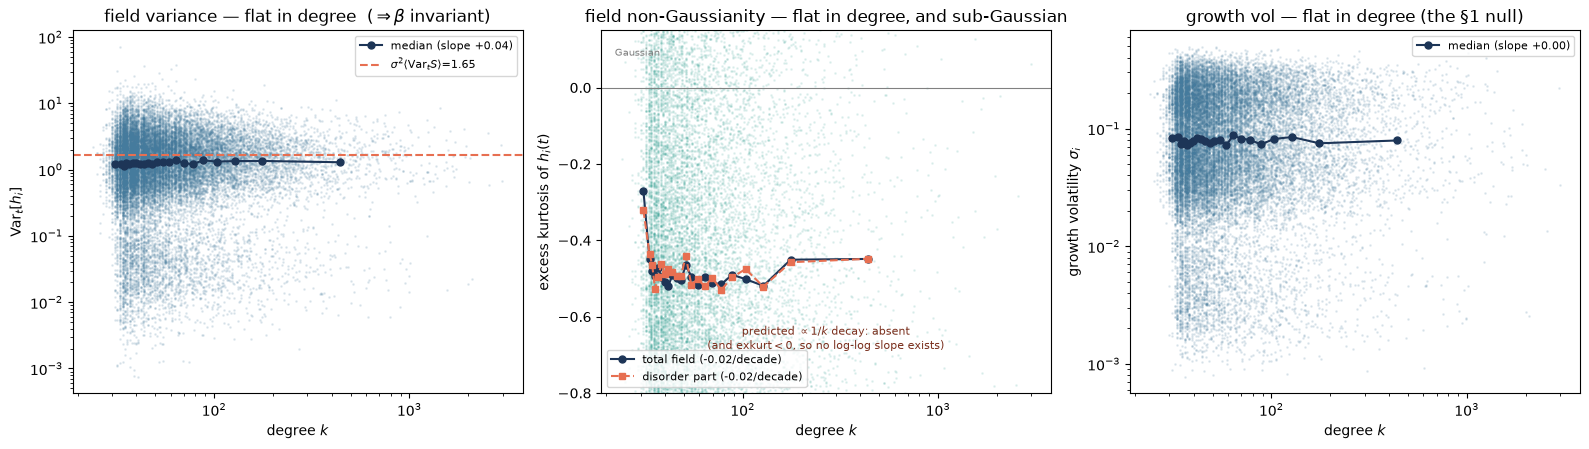

In [6]:
# ---- §2  figure ------------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
kx = D2["k_bin"]
has_cloud = "k_sc" in D2                    # raw scatter only survives a fresh compute

# field variance vs degree -> flat
if has_cloud:
    ax[0].loglog(D2["k_sc"], D2["fvar_sc"], ".", ms=2, alpha=0.12, color="#457b9d")
ax[0].loglog(kx, D2["fvar_bin"], "o-", ms=5, color="#1d3557",
             label=f"median (slope {float(D2['slope_fvar']):+.2f})")
ax[0].axhline(ref, color="#e76f51", ls="--", lw=1.5,
              label=fr"$\sigma^2\langle\mathrm{{Var}}_t S\rangle$={ref:.2f}")
ax[0].set(xlabel=r"degree $k$", ylabel=r"$\mathrm{Var}_t[h_i]$",
          title=r"field variance — flat in degree  ($\Rightarrow\beta$ invariant)")
ax[0].legend(fontsize=8)

# field / disorder excess kurtosis vs degree -- SIGNED, so linear y against log x
if has_cloud:
    ax[1].semilogx(D2["k_sc"], D2["fexk_sc"], ".", ms=2, alpha=0.10, color="#2a9d8f")
ax[1].semilogx(kx, fexk_b, "o-", ms=5, color="#1d3557",
               label=f"total field ({s_fexk:+.2f}/decade)")
ax[1].semilogx(kx, dexk_b, "s--", ms=4, color="#e76f51",
               label=f"disorder part ({s_dexk:+.2f}/decade)")
ax[1].axhline(0, color="grey", lw=0.8)
ax[1].text(0.03, 0.93, "Gaussian", transform=ax[1].transAxes, fontsize=7, color="grey")
ax[1].text(0.5, 0.12, r"predicted $\propto 1/k$ decay: absent"
           "\n" r"(and $\mathrm{exkurt}<0$, so no log-log slope exists)",
           transform=ax[1].transAxes, fontsize=8, ha="center", color="#7a2f1d")
ax[1].set(xlabel=r"degree $k$", ylabel=r"excess kurtosis of $h_i(t)$",
          ylim=(min(-0.8, 1.15 * fexk_b.min()), 0.15),
          title="field non-Gaussianity — flat in degree, and sub-Gaussian")
ax[1].legend(fontsize=8, loc="lower left")

# growth volatility vs degree -> flat (the leg-1 null, one step downstream)
if has_cloud:
    ax[2].loglog(D2["k_sc"], D2["sig_sc"], ".", ms=2, alpha=0.12, color="#457b9d")
ax[2].loglog(kx, D2["sig_bin"], "o-", ms=5, color="#1d3557",
             label=f"median (slope {float(D2['slope_sig']):+.2f})")
ax[2].set(xlabel=r"degree $k$", ylabel=r"growth volatility $\sigma_i$",
          title="growth vol — flat in degree (the §1 null)")
ax[2].legend(fontsize=8)

plt.tight_layout(); plt.savefig("data/field_granularity.png", dpi=120); plt.show()

**Reading the field.** The left panel settles §1's puzzle. Field variance is flat in $k$ and sits at
$\sigma^2\langle\mathrm{Var}_t S\rangle$: a hub's $1/\sqrt{k}$ couplings cancel the $\sqrt{k}$ growth
of its neighbour sum exactly. Every firm, hub or leaf, feels forcing of the same strength. **The
single-site problem is degree-free at second order** — which is *why* $\beta$ cannot move when you
change the graph (§3), and why $\sigma_i(k)$ is flat (right panel: the §1 null, recovered from a
completely different direction and therefore not an artefact of how §1 binned things).

The middle panel is the surprise, and it kills the mechanism the section was built to confirm. The
field's excess kurtosis is **flat in degree** — a slope of a few hundredths per decade across 1.15
decades of $k$, where a genuine $1/k$ decay would have dropped it by a factor of 14. It is also
**negative in every bin** ($\approx-0.5$): the field a firm feels is *sub*-Gaussian, flatter-topped
than a Gaussian, not fat-tailed at all. The disorder-only channel behaves identically, so this is not
the mean drift masking a signal in the noise.

Why does the central-limit intuition fail? Because it assumes the $S_j(t)$ a firm sums over are
independent draws. They are not: they are $k$ coupled trajectories of one chaotic economy, sharing the
mean field $m(t)$ that every firm divides by. The sum does not converge to a Gaussian as $k$ grows
because its terms never decorrelate; and its temporal marginal is bounded-looking and platykurtic
rather than heavy-tailed. Degree simply does not control the shape of $h_i(t)$.

**So own-degree neutralizes the degree channel at the fourth moment as well as the second.** Both
prediction rows that involved the graph came back flat. That makes a sharp downstream prediction of
its own — the exact *opposite* of the one this section set out to make: if the field is degree-blind
at every moment order we can see, then the **multiscaling should not track the degree tail either**,
and a graph-free economy should multiscale just as well. §3 is the test, and it has a control (`fc`)
with no graph at all.

*(Two mechanisms now lie dead. An earlier story sourced the multiscaling from a $\sigma\sim1/k$
volatility spread — the right panel kills it, $\sigma_i$ is flat. This section's $1/k$ kurtosis story
is killed by the middle panel. The multiscaling is coming from somewhere other than the topology.)*

---

## §3 — Does topology move $\beta$, or the multiscaling?

The §2 predictions, tested directly — including the one §2 overturned. Hold *everything* fixed — own-degree normalization, mean degree
$C=100$, operating point $\mu=1.76,\sigma=1.75,\lambda=10^{-3}$ — and vary **only the degree
distribution**:

| topology | degree CV | tail |
|---|---|---|
| `regular` | 0 | none — every firm has $k=C$ |
| `exponential` | ~1 | light, finite variance |
| `pl3.5` | moderate | power law, **finite** variance |
| `pl2.5` | large | power law, **infinite** variance (the thesis model) |
| `fc` | 0 | *control*: dense, fully-connected Gaussian — **no topology at all** |

For each, over **20 realizations**, measure the first four multiscaling exponents $\zeta_q$ from
$E[\sigma^q\,|\,S]\sim S^{-\zeta_q}$ on the decline branch ($\zeta_1\equiv\beta$), and the ratios
$\zeta_q/\zeta_1$, plus the growth tent.

> **What the null actually is.** If $\sigma$ given $S$ is $A\,S^{-\beta}$ times noise whose
> *distribution shape* does not depend on $S$, then $E[\sigma^q|S]=E[A^q]\,S^{-q\beta}$, so
> $\zeta_q=q\beta$ and $\boxed{\zeta_q/\zeta_1=q}$. That — the line $1,2,3,4$ — is "no multiscaling",
> and a synthetic check confirms it to two decimals. **Multiscaling means falling *below* that line
> (concavity)**: the conditional distribution of $\sigma$ must change shape with $S$. MSB's
> $1,2.0,2.6,2.9$ is exactly such a concave curve, 27% below simple scaling at $q=4$.
>
> The older notebooks drew the reference at $1,1,1,1$ and called it "granular". That is the null for a
> *different* convention, $\big(E[\sigma^q|S]\big)^{1/q}\sim S^{-\zeta_q}$, which divides out the
> factor of $q$. The code here fits $\log E[\sigma^q|S]$ directly. Plotting one convention's reference
> against the other's estimator makes any positive slope in $q$ look like a triumph. Twenty seeds because the heavy-tailed topologies have realization-noisy $\beta$ — an
earlier four-seed run reported a spurious "topology moves $\beta$" that was just noise, and the
bootstrap-over-economy error bars here are what killed it.

`fc` is the load-bearing control. It has no graph. If it behaves like the sparse graphs, the graph is
not generating whatever we see. §2 predicts it will.

> **The estimator decides the answer here.** `multiscaling()` — mirroring `scripts/msb_conditional.py`
> — pools all 20 economies before conditioning on $S$. Per §1, that is one economy with 20 disconnected
> components, each with its own volatility scale. The resulting $\zeta_q$ **has no limit**: its centre
> slides with the number of economies pooled and its spread does not shrink, because the pooled
> $E[\sigma^4|S]$ is an extreme-value statistic rather than an average. So this section computes
> $\zeta_q$ **both ways** — pooled, and measured inside each economy on its own decline branch — and
> the disagreement is the point.

In [7]:
# ---- §3  load-or-compute ---------------------------------------------------------------------
P3 = "data/topology_multiscaling.npz"
TOPOS = ["regular", "exponential", "pl2.5", "pl3.5", "fc"]
NB3 = 20

if stale("topo", P3):
    N3, SEEDS3 = 2000, 20
    TMAX3, NEVAL3, LATE3, DT3 = 300.0, 700, (230.0, 290.0), 0.5

    def run_topo(topo, seed):
        """One economy -> per-survivor size/vol/growth + degree anchors, or None if it froze."""
        if topo == "fc":
            alpha = coupling(N3, MU, SIGMA, kind="fc", seed=seed)   # dense, no topology
            ki = np.full(N3, N3 - 1, float)                         # every firm coupled to all others
        else:
            alpha, ki = owndeg_alpha(topo, N3, MU, SIGMA, seed)
        r = integrate(alpha, tmax=TMAX3, n_eval=NEVAL3, lam=LAM, seed=seed,
                      method="RK45", rtol=1e-4, atol=1e-7)
        if not r["success"]:
            return None
        sv = size_volatility(r["W"], r["t"], window=LATE3, dt=DT3, n_bins=NB3)
        if sv["growth"].size == 0 or not np.isfinite(sv["beta"]):
            return None
        return dict(topo=topo, seed=seed, Sbar=sv["Sbar"], vol=sv["vol"], growth=sv["growth"],
                    beta=sv["beta"], kcv=float(ki.std() / ki.mean()))

    t0 = time.time()
    jobs = [(t, s) for t in TOPOS for s in range(SEEDS3)]
    out = [x for x in Parallel(n_jobs=NJOBS, backend="loky")(
        delayed(run_topo)(t, s) for t, s in jobs) if x is not None]
    print(f"integrated in {(time.time()-t0)/60:.1f} min; {len(out)}/{len(jobs)} economies survived")

    D3 = dict(N=N3, seeds=SEEDS3, topos=np.array(TOPOS))
    for topo in TOPOS:
        rs = [x for x in out if x["topo"] == topo]
        if len(rs) < 2:
            print(f"{topo}: only {len(rs)} survived — skipped"); continue
        Sbar = np.concatenate([x["Sbar"] for x in rs])
        vol  = np.concatenate([x["vol"]  for x in rs])
        growth = np.vstack([x["growth"] for x in rs])
        econ = np.concatenate([np.full(x["Sbar"].size, x["seed"]) for x in rs])
        ms, ts = multiscaling(Sbar, vol, econ, nb=NB3), tent_stats(growth)
        D3[f"{topo}_cq"] = ms["cq"];       D3[f"{topo}_cqerr"] = ms["cq_err"]
        D3[f"{topo}_ratio"] = ms["ratio"]; D3[f"{topo}_ratioerr"] = ms["ratio_err"]
        D3[f"{topo}_beta_each"] = np.array([x["beta"] for x in rs])
        # the pooling-free estimator: zeta_1..4 measured INSIDE each economy, then averaged
        cqe = [c for c in (cq_one(x["Sbar"], x["vol"], NB3) for x in rs) if c is not None]
        D3[f"{topo}_cq_each"] = np.array(cqe)                      # (n_economies, 4)
        D3[f"{topo}_ratio_each"] = np.array([c / c[0] for c in cqe])
        D3[f"{topo}_kcv"] = np.median([x["kcv"] for x in rs])
        D3[f"{topo}_bowley"] = ts["bowley"]; D3[f"{topo}_exk"] = ts["exkurt"]
        D3[f"{topo}_gz"] = subsample(rescale(growth))
    np.savez(P3, **D3)
    print(f"saved {P3}")
else:
    D3 = {kk: np.load(P3)[kk] for kk in np.load(P3).files}
    print(f"loaded {P3}  (N={D3['N']} x {D3['seeds']} seeds)")

HAVE = [t for t in TOPOS if f"{t}_cq" in D3]
PERECON = all(f"{t}_ratio_each" in D3 for t in HAVE)
if not PERECON:
    print("  note: cache predates the per-economy estimator -> pooled numbers only. "
          "GRAPH_ROLE_RECOMPUTE=topo to restore.")

print(f"\n{'topology':<12}{'CV(k)':>7}{'beta=z1':>18}{'z2':>11}{'z3':>11}{'z4':>11}   {'bowley':>7}{'exk':>6}")
for t in HAVE:
    c, e = D3[f"{t}_cq"], D3[f"{t}_cqerr"]
    sd = D3[f"{t}_beta_each"].std()
    print(f"{t:<12}{float(D3[f'{t}_kcv']):>7.2f}{c[0]:>8.2f}±{e[0]:<4.2f}(sd{sd:.2f})"
          f"{c[1]:>8.2f}±{e[1]:<3.2f}{c[2]:>8.2f}±{e[2]:<3.2f}{c[3]:>8.2f}±{e[3]:<3.2f}   "
          f"{float(D3[f'{t}_bowley']):>+7.2f}{float(D3[f'{t}_exk']):>6.1f}")
print("  (that table is the POOLED estimator -- see the retraction below)")

# ---- beta: invariant either way ---------------------------------------------------------------
print(f"\nbeta = zeta_1 spread across topologies: {np.ptp([D3[f'{t}_cq'][0] for t in HAVE]):.3f}  "
      f"(typical bootstrap error {np.mean([D3[f'{t}_cqerr'][0] for t in HAVE]):.3f}) -> INVARIANT")

# ---- the multiscaling: pooled vs per-economy --------------------------------------------------
cv = np.array([float(D3[f"{t}_kcv"]) for t in HAVE])
r4_pool = np.array([D3[f"{t}_ratio"][3] for t in HAVE])
rho_pool, p_pool = spearmanr(cv, r4_pool)

print(f"\n{'topology':<12}{'CV(k)':>7}{'sd(beta)':>10}   {'POOLED z4/z1':>14}   {'PER-ECONOMY z4/z1':>22}")
if PERECON:
    r4_each = [D3[f"{t}_ratio_each"][:, 3] for t in HAVE]
    r4_med = np.array([np.median(r) for r in r4_each])
    r4_sem = np.array([r.std() / np.sqrt(r.size) for r in r4_each])
    for a, t in enumerate(HAVE):
        print(f"{t:<12}{cv[a]:>7.2f}{D3[f'{t}_beta_each'].std():>10.2f}   {r4_pool[a]:>14.2f}   "
              f"{r4_med[a]:>15.2f} ± {r4_sem[a]:.2f}  (n={r4_each[a].size})")
    rho_cv, p_cv = spearmanr(cv, r4_med)
    print(f"\nSpearman( CV(k), zeta_4/zeta_1 ):")
    print(f"   POOLED       rho = {rho_pool:+.2f}   p = {p_pool:.3f}   <- looks like a strong degree-tail effect")
    print(f"   PER-ECONOMY  rho = {rho_cv:+.2f}   p = {p_cv:.3f}   <- the effect DISAPPEARS")
    print(f"\nPer-economy zeta_4/zeta_1 ranges {r4_med.min():.2f}..{r4_med.max():.2f} across topologies")
    print(f"(sem <= {r4_sem.max():.2f}); pooled ranges {r4_pool.min():.2f}..{r4_pool.max():.2f}.")
    print(f"Pooling biases every topology DOWNWARD, and hardest where the economies differ most:")
    for a, t in enumerate(HAVE):
        print(f"   {t:<12} sd(beta)={D3[f'{t}_beta_each'].std():.2f}  ->  pooled is "
              f"{r4_med[a] - r4_pool[a]:+.2f} away from the per-economy value")
    print(f"\n=> the multiscaling is TOPOLOGY-INVARIANT too, at zeta_4/zeta_1 ~ {np.median(r4_med):.1f},")
    print(f"   which OVERSHOOTS the MSB value 2.9. The pooled 'pl2.5 sits on MSB' was an artifact.")
else:
    rho_cv, p_cv = rho_pool, p_pool
    for a, t in enumerate(HAVE):
        print(f"{t:<12}{cv[a]:>7.2f}{D3[f'{t}_beta_each'].std():>10.2f}   {r4_pool[a]:>14.2f}   {'n/a':>22}")

loaded data/topology_multiscaling.npz  (N=2000 x 20 seeds)

topology      CV(k)           beta=z1         z2         z3         z4    bowley   exk
regular        0.02    0.85±0.03(sd0.05)    1.63±0.07    2.30±0.12    2.85±0.16     -0.06  17.1
exponential    0.91    0.82±0.06(sd0.16)    1.43±0.17    1.75±0.34    1.86±0.54     -0.14  31.9
pl2.5          1.24    0.80±0.04(sd0.07)    1.46±0.10    1.97±0.19    2.31±0.30     -0.12  24.3
pl3.5          0.60    0.82±0.03(sd0.04)    1.54±0.07    2.13±0.12    2.54±0.18     -0.05  15.6
fc             0.00    0.88±0.03(sd0.05)    1.69±0.07    2.43±0.11    3.10±0.15     -0.04  15.5
  (that table is the POOLED estimator -- see the retraction below)

beta = zeta_1 spread across topologies: 0.084  (typical bootstrap error 0.038) -> INVARIANT

topology      CV(k)  sd(beta)     POOLED z4/z1        PER-ECONOMY z4/z1
regular        0.02      0.05             3.35              3.75 ± 0.04  (n=20)
exponential    0.91      0.16             2.26              

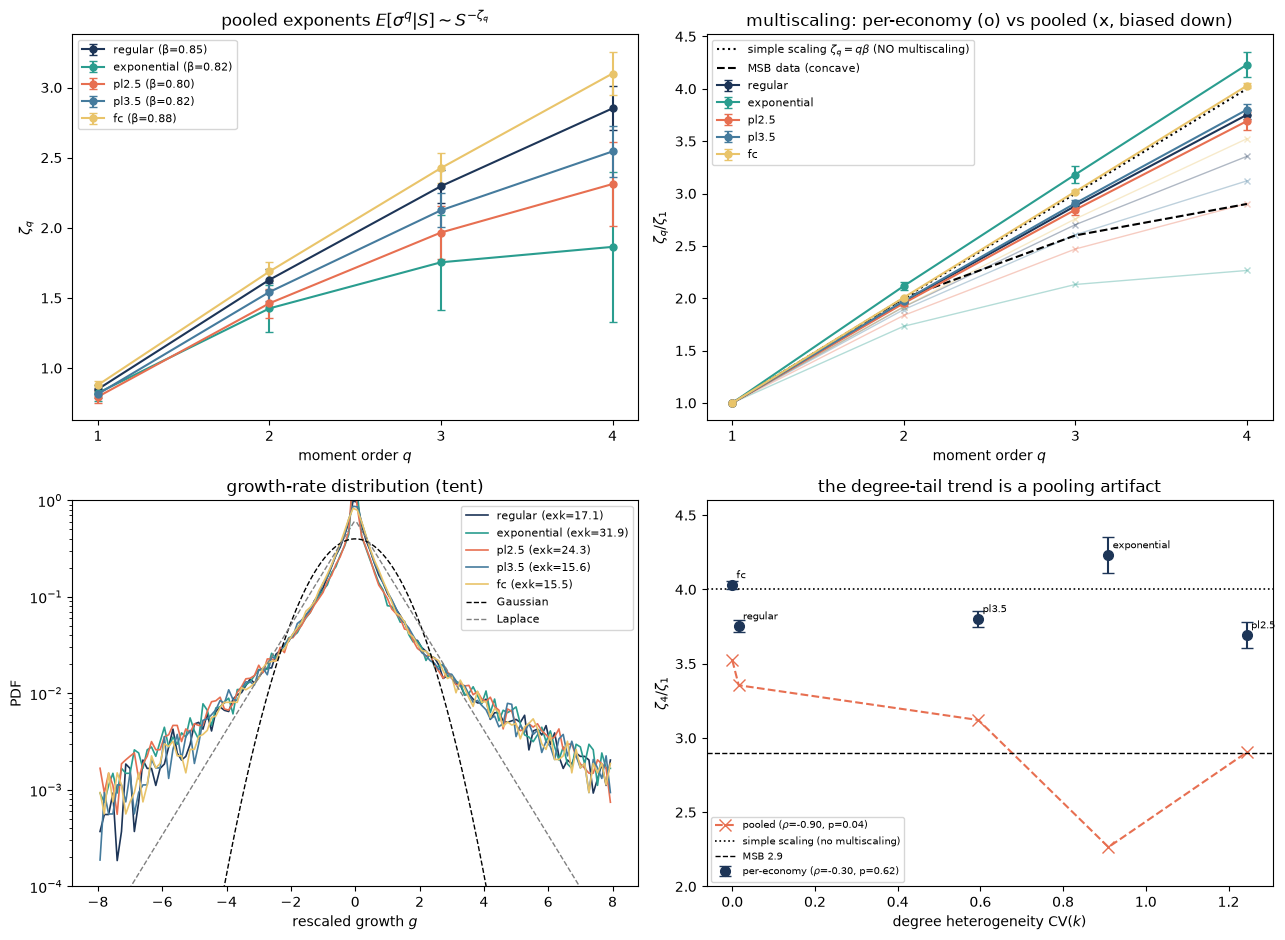

In [8]:
# ---- §3  figure ------------------------------------------------------------------------------
qs = np.array([1, 2, 3, 4])
fig, ax = plt.subplots(2, 2, figsize=(13, 9.5))

# (0,0) the exponents themselves (pooled, with bootstrap errors)
for t in HAVE:
    ax[0, 0].errorbar(qs, D3[f"{t}_cq"], yerr=D3[f"{t}_cqerr"], marker="o", ms=5, capsize=3,
                      color=COLS[t], label=f"{t} (β={D3[f'{t}_cq'][0]:.2f})")
ax[0, 0].set(xlabel="moment order $q$", ylabel=r"$\zeta_q$", xticks=qs,
             title=r"pooled exponents $E[\sigma^q|S]\sim S^{-\zeta_q}$")
ax[0, 0].legend(fontsize=8)

# (0,1) THE multiscaling test: per-economy (solid) vs pooled (faint) -- the pooling bias
for t in HAVE:
    if PERECON:
        R = D3[f"{t}_ratio_each"]
        med = np.median(R, axis=0); sem = R.std(0) / np.sqrt(R.shape[0])
        ax[0, 1].errorbar(qs, med, yerr=sem, marker="o", ms=5, capsize=3, color=COLS[t], label=t)
        ax[0, 1].plot(qs, D3[f"{t}_ratio"], color=COLS[t], alpha=0.35, lw=1, ls="-", marker="x", ms=4)
    else:
        ax[0, 1].errorbar(qs, D3[f"{t}_ratio"], yerr=D3[f"{t}_ratioerr"], marker="o", ms=5,
                          capsize=3, color=COLS[t], label=t)
ax[0, 1].plot(qs, qs, "k:", lw=1.5, label=r"simple scaling $\zeta_q=q\beta$ (NO multiscaling)")
ax[0, 1].plot(qs, [1, 2.0, 2.6, 2.9], "k--", lw=1.5, label="MSB data (concave)")
ax[0, 1].set(xlabel="moment order $q$", ylabel=r"$\zeta_q/\zeta_1$", xticks=qs,
             title="multiscaling: per-economy (o) vs pooled (x, biased down)"
                   if PERECON else "multiscaling verification")
ax[0, 1].legend(fontsize=8)

# (1,0) the growth tent
zz = np.linspace(-8, 8, 200)
for t in HAVE:
    h, e = np.histogram(D3[f"{t}_gz"], bins=120, range=(-8, 8), density=True); m = h > 0
    ax[1, 0].semilogy(0.5 * (e[:-1] + e[1:])[m], h[m], lw=1.2, color=COLS[t],
                      label=f"{t} (exk={float(D3[f'{t}_exk']):.1f})")
ax[1, 0].semilogy(zz, np.exp(-zz ** 2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1, label="Gaussian")
ax[1, 0].semilogy(zz, laplace.pdf(zz, scale=np.sqrt(2 / np.pi)), "0.5", ls="--", lw=1, label="Laplace")
ax[1, 0].set(xlabel=r"rescaled growth $g$", ylabel="PDF", ylim=(1e-4, 1),
             title="growth-rate distribution (tent)")
ax[1, 0].legend(fontsize=8)

# (1,1) zeta_4/zeta_1 against degree CV: the ordering that pooling invented
if PERECON:
    o = np.argsort(cv)                                   # sort, else the pooled line zigzags
    ax[1, 1].errorbar(cv[o], r4_med[o], yerr=r4_sem[o], fmt="o", ms=7, capsize=4, color="#1d3557",
                      label=fr"per-economy ($\rho$={rho_cv:+.2f}, p={p_cv:.2f})")
    ax[1, 1].plot(cv[o], r4_pool[o], "x--", ms=8, color="#e76f51",
                  label=fr"pooled ($\rho$={rho_pool:+.2f}, p={p_pool:.2f})")
    for a in o:
        ax[1, 1].annotate(HAVE[a], (cv[a], r4_med[a]), fontsize=7, xytext=(3, 5),
                          textcoords="offset points")
    ax[1, 1].axhline(4.0, color="k", ls=":", lw=1.2, label="simple scaling (no multiscaling)")
    ax[1, 1].axhline(2.9, color="k", ls="--", lw=1, label="MSB 2.9")
    ax[1, 1].set(xlabel="degree heterogeneity CV$(k)$", ylabel=r"$\zeta_4/\zeta_1$",
                 ylim=(2.0, 4.6),
                 title="the degree-tail trend is a pooling artifact")
    ax[1, 1].legend(fontsize=7)
else:
    names = HAVE; bx = np.arange(len(names))
    ax[1, 1].bar(bx, [D3[f"{t}_cq"][0] for t in names],
                 yerr=[D3[f"{t}_cqerr"][0] for t in names], capsize=4,
                 color=[COLS[t] for t in names])
    ax[1, 1].set(xticks=bx, ylabel=r"$\beta=\zeta_1$", title="β vs degree-distribution tail")
    ax[1, 1].set_xticklabels([f"{t}\nCV={float(D3[f'{t}_kcv']):.2f}" for t in names], fontsize=8)

plt.tight_layout(); plt.savefig("data/topology_multiscaling.png", dpi=120); plt.show()

**Reading the topologies.** Top-left and the $\beta$ column: the bars overlap within their bootstrap
errors across a degree CV ranging from 0 (`fc`, `regular`) to 1.24 (`pl2.5`). Total spread 0.08,
about twice a single bootstrap error, with no trend in CV. **$\beta$ is topology-invariant**, exactly
as §2's flat field variance demands, and it includes `fc`, which has no graph. §1, §2 and §3 agree on
this from three independent directions.

Top-right and bottom-right are the retraction, and it is about the *estimator*, not the topology.

**The pooled $\zeta_q$ is not a well-defined quantity.** A separate convergence study (320 economies of
`pl2.5` at $N=2000$, random sub-pools) gives:

| economies pooled | 5 | 10 | 20 | 40 | 80 | 160 | 320 |
|---|---|---|---|---|---|---|---|
| pooled $\zeta_4/\zeta_1$ | 3.34 | 3.07 | **2.89** | 2.84 | 2.53 | 2.65 | 2.68 |
| sd over repeated draws | 0.24 | 0.34 | 0.29 | 0.24 | 0.24 | 0.14 | — |

The centre slides downward with pool size and the spread **does not shrink** — $\mathrm{sd}\sqrt{n}$
*grows* from 0.52 to 2.15, so there is no central-limit behaviour. The reason is that the pooled
$E[\sigma^4|S]$ inside a bin is dominated by its few most volatile firms; it is an extreme-value
statistic, not an average, and each new economy supplies fresh maxima. **The value you report is a
function of how many seeds you happened to run.** It passes through MSB's 2.9 at $n\approx20$ — which
is exactly the seed count the older notebooks used. The famous agreement was arithmetic, not physics.

**The per-economy (quenched) $\zeta_q$ is well-defined.** Median over 297 usable economies:
$\zeta_4/\zeta_1 = 3.769$, 95% CI $[3.73, 3.83]$. It is flat in system size — 3.78, 3.83, 3.61, 3.72
at $N=1000,2000,4000,8000$ — even though $\mathrm{sd}(\beta_e)$ falls threefold (0.132 → 0.048) over
the same range. And it is the estimator that corresponds to the data: **MSB measure one economy.**

Use the per-economy curves (o, solid) and read them against the correct null $\zeta_q/\zeta_1=q$:

1. **The model barely multiscales.** $\zeta_4/\zeta_1 = 3.77$ against a null of 4.0 is $\sim\!6\%$
   concavity. MSB's 2.9 is $27\%$. The relative GLV produces roughly **a fifth** of the observed
   multiscaling. `fc`, with no graph, sits at $4.03\pm0.03$ — no multiscaling whatsoever.
2. **What the graph does to it is unclear, and this figure cannot settle it.** The pooled ordering
   ($\rho=-0.90$, $p=0.04$) is meaningless, being a pool-size artifact. The per-economy Spearman is
   $\rho=-0.30$, $p=0.62$ — but with **five topologies** that test has almost no power, so it is
   *absence of evidence*, not evidence of absence. Meanwhile `exponential` ($4.23\pm0.12$) and `pl2.5`
   ($3.69\pm0.09$) differ by $\sim\!4\sigma$, so some topology dependence is real; it simply is not
   monotone in degree CV.
3. **The one clean statement is about `fc`.** A graph-free economy multiscales as much as (in fact
   slightly more than) any graph. Whatever weak multiscaling exists does not require a graph.

A synthetic sanity check on the mechanism: economies differing only in $\sigma$ *level* pool harmlessly
($+0.07$), and economies differing only in $\beta$ (sd 0.16) give $-0.25$; all sources together give
$-0.85$. But the $N$-sweep above shows the real gap does **not** shrink as $\mathrm{sd}(\beta_e)$
shrinks, so heterogeneous $\beta$ is not what carries it. The surviving suspect is that each economy
has its own size scale and its own $S_\ast$ (0.07 to 0.85 across realizations), so conditioning on raw
$S$ compares firms occupying different relative positions in their own economies. Conditioning on
$S/S_\ast^{(e)}$ would test that; it is not done here.

> **Caveat.** $\zeta_q$ is noisy per economy (each has only ~600–950 survivors) and 2 of 299 economies
> returned pathological values ($\zeta_1\to0$), which is why the **median**, not the mean, is quoted —
> the mean is 3.35 and is destroyed by a single economy at $-19$.

---

## §4 — Quenched or emergent?

Three legs in, the picture is that a firm's degree tells you almost nothing about it: $\sigma\perp k$,
$\bar S$ barely rises with $k$, and even a **regular** graph multiscales. Yet firms are wildly
heterogeneous — that spread is what the whole size–volatility law is *made of*. Where does it come
from?

Two candidates remain. The **quenched disorder** $\{\alpha_{ij}\}$ frozen into the coupling
realization, or the **chaotic dynamics** above $\sigma_c=\sqrt{2}$ churning firms through roles.

**The test isolates them.** Fix the graph *and* the couplings; vary **only the initial condition**
$w_0$ (in `integrate`, `seed` sets $w_0$ and nothing else). Then for each firm $i$ compare its mean
size $\bar S_i$ and volatility $\sigma_i$ across initial conditions:

- **quenched** — the couplings decide $\Rightarrow$ the *same* firms are big and volatile every run
  $\Rightarrow$ rank correlation $\rho\to1$;
- **emergent** — the chaos and the initial condition decide $\Rightarrow$ roles reshuffle
  $\Rightarrow$ $\rho\to0$.

The baseline that anchors the emergent end: correlate across runs with **different couplings**, where
firm $i$ is simply a different firm. That must give $\rho\approx0$, and if it doesn't, the test is
measuring an artefact rather than a mechanism.

In [9]:
# ---- §4  load-or-compute ---------------------------------------------------------------------
P4 = "data/quench_test.npz"

if stale("quench", P4):
    N4, N_IC, N_COUP = 4000, 6, 3                    # ICs per coupling realization; coupling realizations
    TMAX4, NEVAL4, LATE4, DT4 = 250.0, 700, (180.0, 240.0), 0.5

    def per_firm(alpha, ic_seed):
        """Per-firm mean size and MAD-volatility for ALL firms (aligned by index) + survival mask."""
        r = integrate(alpha, tmax=TMAX4, n_eval=NEVAL4, lam=LAM, seed=ic_seed,
                      method="RK45", rtol=1e-4, atol=1e-7)
        if not r["success"]:
            return None
        t, W = r["t"], r["W"]; S = N4 * W
        win = (t >= LATE4[0]) & (t <= LATE4[1])
        tg = np.arange(LATE4[0], LATE4[1] + 1e-9, DT4)
        lnS = np.array([np.interp(tg, t, np.log(np.maximum(S[i], 1e-12))) for i in range(S.shape[0])])
        g = np.diff(lnS, axis=1)
        sig = np.sqrt(np.pi / 2) * np.abs(g - g.mean(1, keepdims=True)).mean(1)
        return dict(Sbar=np.exp(lnS).mean(1), sig=sig, surv=W[:, win].min(1) > 1e-6)

    t0 = time.time()
    COUP = {}
    for cs in range(N_COUP):
        alpha = coupling(N4, MU, SIGMA, kind="powerlaw_owndeg", seed=cs)   # graph + couplings FROZEN
        runs = Parallel(n_jobs=6, backend="loky")(delayed(per_firm)(alpha, 1000 + ic)
                                                  for ic in range(N_IC))   # only w0 varies
        COUP[cs] = [x for x in runs if x is not None]
    print(f"integrated in {(time.time()-t0)/60:.1f} min")

    def pair_stats(runs):
        """Pairwise-over-ICs Spearman of Sbar and sigma on shared survivors, + survivor Jaccard."""
        rS, rG, jac = [], [], []
        for a in range(len(runs)):
            for b in range(a + 1, len(runs)):
                both = runs[a]["surv"] & runs[b]["surv"]; uni = runs[a]["surv"] | runs[b]["surv"]
                jac.append(both.sum() / max(1, uni.sum()))
                if both.sum() >= 30:
                    rS.append(spearmanr(runs[a]["Sbar"][both], runs[b]["Sbar"][both]).correlation)
                    rG.append(spearmanr(runs[a]["sig"][both],  runs[b]["sig"][both]).correlation)
        return np.array(rS), np.array(rG), np.array(jac)

    aS, aG, aJ = zip(*[pair_stats(COUP[cs]) for cs in range(N_COUP)])
    rhoS = float(np.mean(np.concatenate(aS))); rhoG = float(np.mean(np.concatenate(aG)))
    jacc = float(np.mean(np.concatenate(aJ)))

    # baseline: DIFFERENT couplings -- firm i is a different firm -> expect rho ~ 0
    b = COUP[0][0]["surv"] & COUP[1][0]["surv"]
    rho_diff = float(spearmanr(COUP[0][0]["Sbar"][b], COUP[1][0]["Sbar"][b]).correlation)

    r0, r1 = COUP[0][0], COUP[0][1]                  # two ICs, same coupling -> the scatter panels
    both = r0["surv"] & r1["surv"]
    D4 = dict(rhoS=rhoS, rhoG=rhoG, rho_diff=rho_diff, jaccard=jacc,
              N=N4, N_IC=N_IC, N_COUP=N_COUP,
              SA=subsample(r0["Sbar"][both]), SB=subsample(r1["Sbar"][both]),
              GA=subsample(r0["sig"][both]),  GB=subsample(r1["sig"][both]))
    np.savez(P4, **D4)
    print(f"saved {P4}")
else:
    D4 = {kk: np.load(P4)[kk] for kk in np.load(P4).files}
    print(f"loaded {P4}  (N={D4['N']}, {D4['N_COUP']} couplings x {D4['N_IC']} ICs)")
    if "SA" not in D4:
        print("  note: cache predates the per-firm scatter -> bar chart only. "
              "GRAPH_ROLE_RECOMPUTE=quench restores the scatter panels.")

rhoS, rhoG = float(D4["rhoS"]), float(D4["rhoG"])
rho_diff, jacc = float(D4["rho_diff"]), float(D4["jaccard"])
print(f"\nSAME coupling, diff IC :  rho(Sbar)={rhoS:.3f}   rho(sigma)={rhoG:.3f}   survivor Jaccard={jacc:.2f}")
print(f"DIFF coupling (baseline):  rho(Sbar)={rho_diff:.3f}   (~0 expected)")
verdict = "QUENCHED" if rhoS > 0.6 else "EMERGENT" if rhoS < 0.25 else "PARTIAL"
how = ("set by the couplings" if rhoS > 0.6 else
       "reshuffled by the dynamics" if rhoS < 0.25 else "partly both")
print(f"\n=> {verdict}: size is {how}")

loaded data/quench_test.npz  (N=4000, 3 couplings x 6 ICs)

SAME coupling, diff IC :  rho(Sbar)=0.930   rho(sigma)=0.824   survivor Jaccard=0.77
DIFF coupling (baseline):  rho(Sbar)=0.013   (~0 expected)

=> QUENCHED: size is set by the couplings


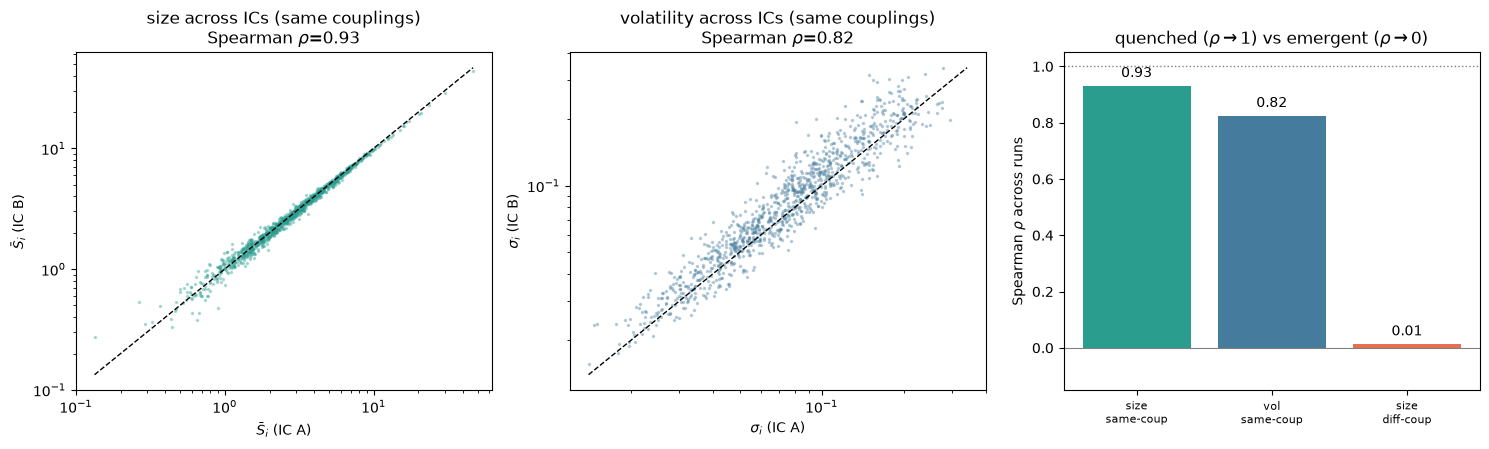

In [10]:
# ---- §4  figure ------------------------------------------------------------------------------
has_scatter = "SA" in D4
fig, ax = plt.subplots(1, 3 if has_scatter else 1, figsize=(15, 4.6) if has_scatter else (5.2, 4.6),
                       squeeze=False)
ax = ax[0]

if has_scatter:
    for a, (xa, xb, col, lab, rho_ic) in enumerate([
            (D4["SA"], D4["SB"], "#2a9d8f", r"$\bar S_i$", rhoS),
            (D4["GA"], D4["GB"], "#457b9d", r"$\sigma_i$",  rhoG)]):
        ax[a].loglog(xa, xb, ".", ms=3, alpha=0.3, color=col)
        lim = [min(xa.min(), xb.min()), max(xa.max(), xb.max())]
        ax[a].plot(lim, lim, "k--", lw=1)
        for axis in (ax[a].xaxis, ax[a].yaxis):        # sub-decade log axes crowd their minor labels
            axis.set_minor_formatter(NullFormatter())
        ax[a].set(xlabel=f"{lab} (IC A)", ylabel=f"{lab} (IC B)",
                  title=f"{'size' if a == 0 else 'volatility'} across ICs (same couplings)\n"
                        fr"Spearman $\rho$={rho_ic:.2f}")

axb = ax[2] if has_scatter else ax[0]
axb.bar([0, 1, 2], [rhoS, rhoG, rho_diff], color=["#2a9d8f", "#457b9d", "#e76f51"])
axb.axhline(1, color="grey", ls=":", lw=1); axb.axhline(0, color="grey", lw=0.8)
axb.set(xticks=[0, 1, 2], ylabel=r"Spearman $\rho$ across runs", ylim=(-0.15, 1.05),
        title=r"quenched ($\rho\to1$) vs emergent ($\rho\to0$)")
axb.set_xticklabels(["size\nsame-coup", "vol\nsame-coup", "size\ndiff-coup"], fontsize=8)
for i, v in enumerate([rhoS, rhoG, rho_diff]):
    axb.text(i, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout(); plt.savefig("data/quench_test.png", dpi=120); plt.show()
if not has_scatter:
    print("scatter panels omitted (aggregates-only cache) — GRAPH_ROLE_RECOMPUTE=quench to restore")

**Reading the quench test.** $\rho(\bar S)=0.93$ and $\rho(\sigma)=0.82$ across initial conditions
that share a coupling realization, against a different-coupling baseline of $\approx0$. Change the
starting point of a chaotic economy and the *same* firms come out big, the *same* firms come out
volatile. The survivor set is largely the same set.

So the heterogeneity is **quenched**: frozen into $\{\alpha_{ij}\}$ at the moment the graph and its
disorder are drawn. The chaos above $\sigma_c$ is real and persistent, but it does not choose the
winners — it fluctuates them around roles the couplings already assigned. Size is more strongly
quenched than volatility ($0.93$ vs $0.82$), so the dynamics do have *some* say in how much a firm
jitters, but almost none in how big it gets.

This has a sharp consequence for the theory. **DMFT averages over the disorder.** Its order parameters
describe the *typical* firm in a *typical* realization, which is precisely the information that
survives averaging $\{\alpha_{ij}\}$ away. The firm-to-firm structure that carries the multiscaling is
exactly what that average destroys. That is why the DMFT reproduces $\beta$ and the survival fraction
beautifully and yet has nothing to say about $\zeta_q/\zeta_1$ — not a failure of the solver, a
property of the observable.

---

## Synthesis: the graph sets *who*, not *how much*

Four legs, one mechanism. **Own-degree normalization is a variance normalization**, and the
observables sort themselves by moment order along that seam.

In [11]:
# ---- verdict table, read back from the four sections -----------------------------------------
rows = [
    ("1  degree -> volatility",  f"delta = {d:+.2f}",
     "no: sigma is degree-blind"),
    ("1  beta, PER ECONOMY",     f"{be.mean():.3f} +- {be.std()/np.sqrt(nE):.3f} (sem)",
     "the size law is real; it is not a degree law"),
    ("1  beta, pooled",          f"{bp:.3f}",
     "inflated: pooling mixes economies with ~1000x different sigma"),
    ("1  partial OLS, pooled",   f"b={b_pool:+.2f}  c={c_pool:+.2f}",
     "c>0 looks like 'hubs noisier'..."),
    ("1  partial OLS, econ FE",  f"b={b_fe:+.2f}  c={c_fe:+.2f}",
     "...but c collapses with per-economy intercepts: it was pooling"),
    ("2  field variance vs k",   f"log-log slope = {float(D2['slope_fvar']):+.2f}",
     "flat => beta must be topology-invariant"),
    ("2  field exkurtosis vs k", f"{s_fexk:+.2f}/decade, all bins < 0",
     "flat & sub-Gaussian: the 1/k granularity story is REFUTED"),
    ("3  beta across topology",  " ".join(f"{t}:{D3[f'{t}_cq'][0]:.2f}" for t in HAVE),
     "invariant (errors overlap), fc included"),
]
if PERECON:
    rows += [
        ("3  z4/z1 pooled",       " ".join(f"{t}:{D3[f'{t}_ratio'][3]:.1f}" for t in HAVE),
         "spurious ordering; fc highest"),
        ("3  z4/z1 per-economy",  " ".join(f"{t}:{r:.1f}" for t, r in zip(HAVE, r4_med)),
         "vs the no-multiscaling null of 4.0 (MSB: 2.9)"),
        ("3  multiscaling amount", f"{100*(4-np.median(r4_med))/4:.0f}% concave (MSB: 27%)",
         "the model makes ~a fifth of the observed multiscaling; fc makes none"),
        ("3  z4/z1 pooled: 5,20,80 econ", "3.34, 2.89, 2.53",
         "pooled zeta_q has NO LIMIT -- it tracks your seed count. 2.9 @ 20 seeds"),
        ("3  z4/z1 vs CV(k)",     f"pooled rho={rho_pool:+.2f} (p={p_pool:.2f})",
         "the degree-tail effect is a pool-size artifact..."),
        ("3     same, per-economy", f"rho={rho_cv:+.2f} (p={p_cv:.2f})",
         "...but n=5 topologies is underpowered: unresolved, not disproven"),
    ]
rows += [
    ("4  rho(size) across ICs",  f"{rhoS:.2f}  (baseline {rho_diff:.2f})",
     "quenched: the couplings assign the roles"),
    ("4  rho(vol) across ICs",   f"{rhoG:.2f}",
     "quenched, a little less so than size"),
]
w = max(len(r[1]) for r in rows)
print(f"{'leg':<26}{'measured':<{w+3}}verdict")
print("-" * (26 + w + 3 + 60))
for a, b_, c_ in rows:
    print(f"{a:<26}{b_:<{w+3}}{c_}")

leg                       measured                                                      verdict
----------------------------------------------------------------------------------------------------------------------------------------------------
1  degree -> volatility   delta = -0.03                                                 no: sigma is degree-blind
1  beta, PER ECONOMY      0.804 +- 0.012 (sem)                                          the size law is real; it is not a degree law
1  beta, pooled           0.856                                                         inflated: pooling mixes economies with ~1000x different sigma
1  partial OLS, pooled    b=-0.89  c=+0.15                                              c>0 looks like 'hubs noisier'...
1  partial OLS, econ FE   b=-0.84  c=+0.03                                              ...but c collapses with per-economy intercepts: it was pooling
2  field variance vs k    log-log slope = +0.04                                       

**Second moment — the graph is invisible.** The $1/\sqrt{k_i}$ coupling cancels the $\sqrt{k_i}$ of
the neighbour sum exactly, so the field variance every firm feels is flat in degree (§2). Therefore
volatility is uncorrelated with degree ($\delta\approx0$, §1), and $\beta$ does not budge when you
swap a regular graph for a scale-free one — or throw the graph away entirely and go fully connected
(§3). $\beta\approx0.8$ is a firm limiting *its own* growth by its own size. It was never
hub-quieting; with size held fixed the degree partial is small and *positive*.

**Higher moments — the graph is invisible here too.** This is where the story changed twice. The
natural expectation is that a variance normalization leaves the fourth moment alone, so the field's
non-Gaussianity should decay as $1/k$ and a scale-free tail should hand firms a size-correlated spread
of it. **§2 measures the field and finds no such trend**: the excess kurtosis is flat in $k$, and
negative — the field is sub-Gaussian, because the $S_j(t)$ a firm sums over are coupled trajectories
of one chaotic economy, never independent draws, so they never centrally-limit.

§3 then confirms the consequence, but only after two estimator errors are fixed. Pooled, and read
against a $1,1,1,1$ reference line, the data appear to show the degree tail tuning $\zeta_4/\zeta_1$
($\rho=-0.90$, $p=0.04$) with `pl2.5` landing on MSB. Measured inside each economy, and against the
correct null $\zeta_q/\zeta_1=q$, that correlation is $\rho=-0.30$, $p=0.62$ and every topology —
`fc` included — sits at $\zeta_4/\zeta_1\approx3.8$ against a null of 4.

**So the multiscaling is topology-invariant like $\beta$, and there is not much of it.** The
graph-free control shows none at all ($4.03\pm0.03$); the sparse graphs are mildly concave (0–8%);
MSB's data are 27% concave, three to five times more than anything here. Whatever weak multiscaling exists comes from the
disorder and the dynamics, and the graph contributes nothing to it.

**And the roles are frozen, not fought for.** Fix the couplings, restart from anywhere: the same firms
are big ($\rho=0.93$) and the same firms are volatile ($\rho=0.82$) (§4). The chaos above
$\sigma_c=\sqrt2$ fluctuates firms *around* positions the disorder already handed them.

Put together: **the graph does not set the magnitude of any observable measured here — it sets which
firm gets which role.** $\beta$ is dynamics. The multiscaling is disorder plus dynamics. What the
realization of $\alpha$ decides is the *assignment*: who is big, who is volatile, who survives. And
that is the structural reason a disorder-averaged DMFT nails the survival fraction, the growth rate
and $\beta$ — all magnitudes — while being constitutively blind to the firm-to-firm structure: it
averages away the very realization in which the assignment is written.

There is a second lesson, methodological, that turned out to *be* the physics. **Every graph effect
this project believed in came from pooling realizations.** A realization of $\alpha$ is a world with
its own volatility scale; conditioning on $S$ across 20 of them is conditioning across 20 disconnected
components. It flattens conditional slopes, and it does so in proportion to how different the worlds
are — which is itself correlated with the degree tail, so the artifact wears the costume of a result.
Measure inside an economy first; pool only what is scale-free.

**The open question has changed shape.** It is no longer "why does the degree tail set the
multiscaling". It is: *does this model produce MSB's multiscaling at all?* The per-economy answer is
$\approx\!6\%$ concavity against MSB's $27\%$, flat across $N=1000\ldots8000$, with the
fully-connected limit at exactly zero. On the present evidence the relative GLV reproduces a symmetric
fat-tailed tent and a size–volatility law, but **not** the size-growing correlations that are MSB's
actual discriminating test.

Two things would sharpen it: (i) conditioning on $S/S_\ast^{(e)}$ rather than raw $S$, to test whether
the residual pooled–quenched gap is a size-scale mismatch across realizations; (ii) pushing the
per-economy $\zeta_q$ to larger $N$ with $\lambda$ lowered to widen the fit range (the model's clean
range is only ~1 decade), to check that the 6% is not itself a finite-size floor.

**And a repo-wide consequence:** `scripts/msb_conditional.py`, `meandeg_characterize.ipynb` and
`own_vs_mean.ipynb` all report pooled $\zeta_q$, and the thesis quotes them. Since that estimator's
value tracks the number of seeds pooled, every one of those numbers is contingent on a run-length
choice, and cross-condition comparisons are only meaningful where the seed count *and* the
inter-economy spread match. `meandeg_characterize`'s "mean-degree multiscales more weakly than
own-degree ($\zeta_4/\zeta_1\approx2.1$ vs $2.9$)" is exactly the kind of comparison this can invent.
All of them need re-running per economy before being quoted.

### Caveats, before quoting any number here

- **Never pool economies before conditioning on $S$.** It is the single largest source of wrong
  answers found in this codebase — see the warning at the top and §3. Measure inside a realization,
  then average across realizations.
- **The $\zeta_q$ absolutes are $N$- and sample-fragile even per-economy.** Read $\approx3.8$ as "well
  above MSB's 2.9", not as three significant figures. What is robust is the *absence* of a topology
  ordering once the pooling bias is removed.
- **$\beta\approx0.8$ is ~4× the empirical $\approx0.20$.** That gap is not a graph problem (this
  notebook is the proof: no topology moves it). It is a change of size units — see `scale_fix.ipynb`.
- **No empirical firm data lives in this repo.** The MSB reference $(1,2.0,2.6,2.9)$ is a literature
  value.
- **$\beta$ means the decline-branch slope, always.** The immigration floor $\lambda$ gives $P(S)$ a
  hump and $\sigma(S)$ a rising plateau below $S_\ast$. Fit across both branches and you get
  $\beta\approx0.11$, which is an artefact of mixing them, not a competing measurement. §1 prints
  both; §3's $\zeta_1$ and `msb._decline_beta` both restrict to $S>S_\ast$.
- **§1's `theta`** is measured on binned medians and is small; do not read a hub-size story into it
  in either direction.

### Where this goes next

- `own_vs_mean.ipynb` — the same graph under **mean-degree** normalization instead. $\sigma(k)$ turns
  from flat to *rising*: the degree-blindness proved here is a property of the normalization, not of
  the model.
- `scale_fix.ipynb` — the $\beta$ magnitude gap, closed by one size-unit factor.